In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sqlite3

pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")


In [2]:
# 1. Load Trained Models
BASE_DIR = Path("../").resolve()
MODELS_DIR = BASE_DIR / "MODELS_OUTPUT"

models = {}
for model_file in MODELS_DIR.glob("*.joblib"):
    model_name = model_file.stem
    print(f"Loading {model_name}...")
    models[model_name] = joblib.load(model_file)

print("Models loaded successfully!")


Loading Elastic_Net_Tuned...
Loading Hist_Gradient_Boosting_Tuned...
Loading Multiple_Linear_Regression...
Loading Random_Forest_Tuned...
Models loaded successfully!


In [3]:
# 2. Linear Coefficients
def get_linear_coefficients(model_pipeline, top_n=20):
    preprocessor = model_pipeline.named_steps['preprocessor']
    model = model_pipeline.named_steps['model']

    if hasattr(preprocessor, 'get_feature_names_out'):
        feature_names = preprocessor.get_feature_names_out()
    else:
        print("Cannot extract feature names.")
        return None

    coefs = model.coef_
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})

    coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(top_n)

    return coef_df

def plot_coefficients(coef_df, model_name):
    if coef_df is None:
        return
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette="vlag")
    plt.title(f'Top {len(coef_df)} Impactful Features - {model_name}')
    plt.xlabel('Coefficient Value (Impact on Price)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


C:\Users\danie\AppData\Local\Temp\ipykernel_10008\2574840080.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette="vlag")


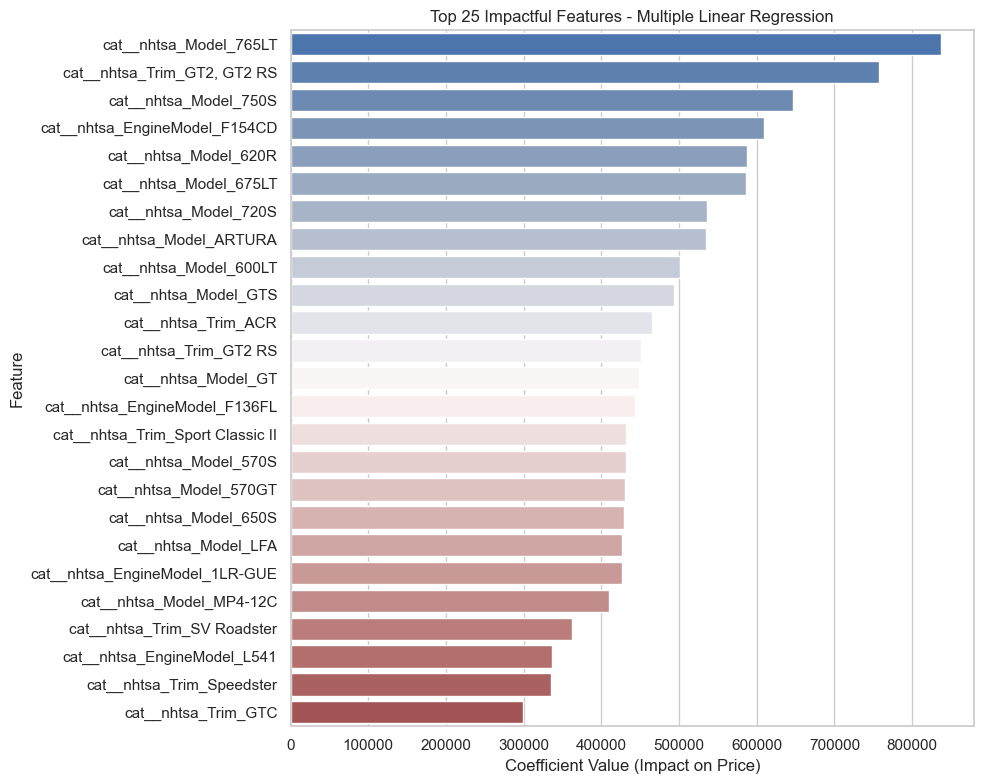

In [4]:
if 'Multiple_Linear_Regression' in models:
    mlr_coefs = get_linear_coefficients(models['Multiple_Linear_Regression'], top_n=25)
    plot_coefficients(mlr_coefs, 'Multiple Linear Regression')


C:\Users\danie\AppData\Local\Temp\ipykernel_10008\2574840080.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette="vlag")


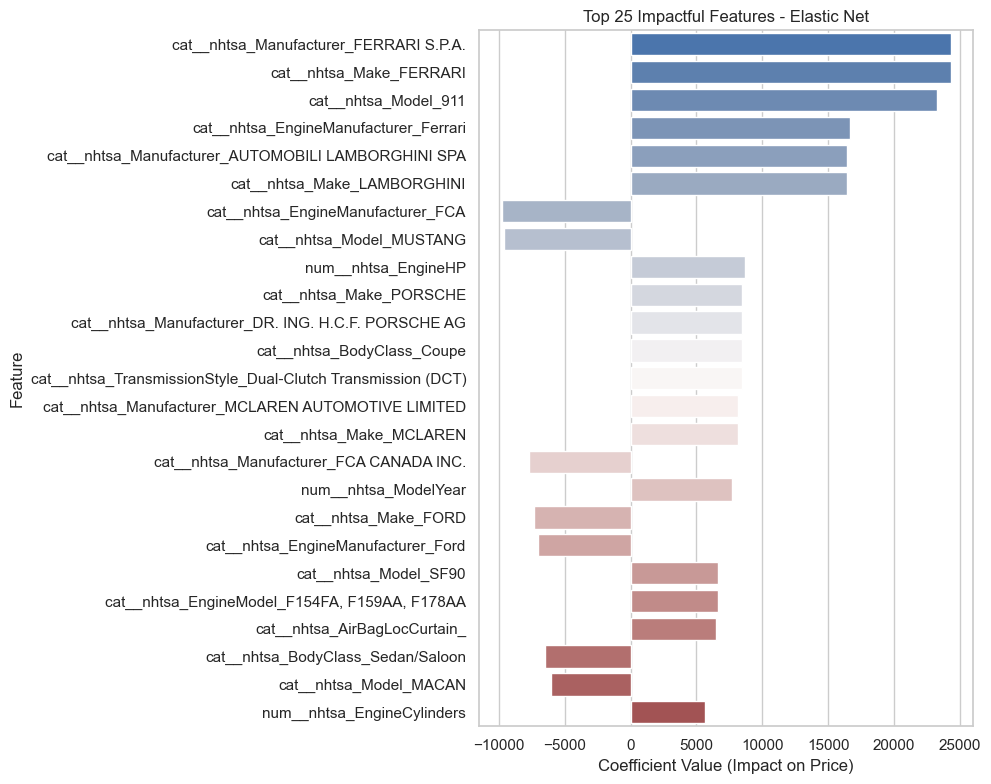

In [5]:
if 'Elastic_Net_Tuned' in models:
    en_coefs = get_linear_coefficients(models['Elastic_Net_Tuned'], top_n=25)
    plot_coefficients(en_coefs, 'Elastic Net')


C:\Users\danie\AppData\Local\Temp\ipykernel_10008\2725058125.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_imp_df, palette="mako")


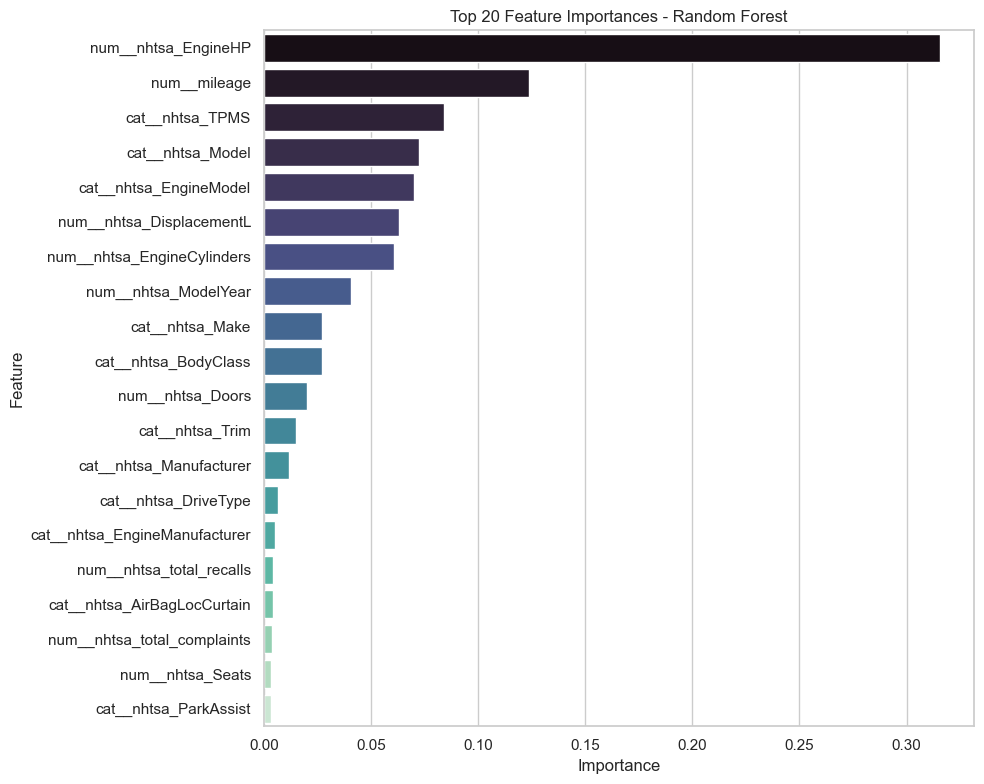

In [6]:
# 3. Random Forest Feature Importances
if 'Random_Forest_Tuned' in models:
    rf_pipeline = models['Random_Forest_Tuned']
    rf_model = rf_pipeline.named_steps['model']
    rf_preprocessor = rf_pipeline.named_steps['preprocessor']

    try:
        feature_names = rf_preprocessor.get_feature_names_out()
        importances = rf_model.feature_importances_

        rf_imp_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values('Importance', ascending=False).head(20)

        plt.figure(figsize=(10, 8))
        sns.barplot(x='Importance', y='Feature', data=rf_imp_df, palette="mako")
        plt.title('Top 20 Feature Importances - Random Forest')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not extract feature importances: {e}")


In [7]:
# 4. Prediction Framework
def predict_price(pipeline, make, model_name, year, trim, mileage, **kwargs):
    expected_features = pipeline.feature_names_in_
    input_dict = {col: np.nan for col in expected_features}

    db_path = BASE_DIR / "CAR_DATA_OUTPUT" / "CAR_DATA_CLEANED.db"
    try:
        conn = sqlite3.connect(db_path)

        query_trim = """
        SELECT * FROM listings l
        JOIN nhtsa_enrichment n ON l.vin = n.vin
        WHERE UPPER(n.nhtsa_Make) = UPPER(?)
          AND UPPER(n.nhtsa_Model) = UPPER(?)
          AND n.nhtsa_ModelYear = ?
          AND UPPER(n.nhtsa_Trim) = UPPER(?)
        LIMIT 1
        """

        query_fallback = """
        SELECT * FROM listings l
        JOIN nhtsa_enrichment n ON l.vin = n.vin
        WHERE UPPER(n.nhtsa_Make) = UPPER(?)
          AND UPPER(n.nhtsa_Model) = UPPER(?)
          AND n.nhtsa_ModelYear = ?
        LIMIT 1
        """

        df_db = pd.read_sql_query(query_trim, conn, params=(make, model_name, str(year), trim))
        if df_db.empty:
            print(f"Warning: Exact trim '{trim}' not found, falling back to Make/Model/Year general baseline.")
            df_db = pd.read_sql_query(query_fallback, conn, params=(make, model_name, str(year)))

        if not df_db.empty:
            for col in expected_features:
                if col in df_db.columns:
                    input_dict[col] = df_db.iloc[0][col]

        conn.close()
    except Exception as e:
        print(f"Database warning during feature retrieval: {e}. Falling back to np.nan")

    make_col = 'nhtsa_Make' if 'nhtsa_Make' in expected_features else 'Make'
    mod_col = 'nhtsa_Model' if 'nhtsa_Model' in expected_features else 'Model'
    yr_col = 'nhtsa_ModelYear' if 'nhtsa_ModelYear' in expected_features else 'year'
    trim_col = 'nhtsa_Trim' if 'nhtsa_Trim' in expected_features else 'Trim'
    mileage_col = 'mileage' if 'mileage' in expected_features else 'Mileage'

    if make_col in input_dict: input_dict[make_col] = str(make)
    if mod_col in input_dict: input_dict[mod_col] = str(model_name)
    if yr_col in input_dict: input_dict[yr_col] = float(year)
    if trim_col in input_dict: input_dict[trim_col] = str(trim)
    if mileage_col in input_dict: input_dict[mileage_col] = float(mileage)

    for k, v in kwargs.items():
        if k in input_dict:
            input_dict[k] = v

    input_data = pd.DataFrame([input_dict], columns=expected_features)

    try:
        prediction = pipeline.predict(input_data)[0]
        return prediction
    except Exception as e:
        print(f"Prediction error: {e}")
        return None


In [8]:
# Example Predictions
def get_actual_average_price(make, model_name, year, trim, mileage, mileage_range=10000, **kwargs):
    db_path = BASE_DIR / "CAR_DATA_OUTPUT" / "CAR_DATA_CLEANED.db"
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()

        query = """
        SELECT AVG(price), COUNT(price)
        FROM listings l
        JOIN nhtsa_enrichment n ON l.vin = n.vin
        WHERE UPPER(n.nhtsa_Make) = UPPER(?)
          AND UPPER(n.nhtsa_Model) = UPPER(?)
          AND n.nhtsa_ModelYear = ?
          AND UPPER(n.nhtsa_Trim) = UPPER(?)
          AND l.mileage BETWEEN ? AND ?
        """

        cursor.execute(query, (make, model_name, str(year), trim, mileage - mileage_range, mileage + mileage_range))
        avg_price, count = cursor.fetchone()
        conn.close()

        return avg_price, count if count else 0
    except Exception as e:
        print(f"Database query error: {e}")
        return None, 0

test_car = {
    'make': 'FORD',
    'model_name': 'MUSTANG',
    'year': 2020,
    'trim': 'Shelby Coupe',
    'mileage': 21000
}

print(f"\n--- Predictions for {test_car['year']} {test_car['make']} {test_car['model_name']} {test_car['trim']} ({test_car['mileage']} miles) ---")

actual_avg, actual_count = get_actual_average_price(**test_car)
if actual_avg is not None and actual_count > 0:
    print(f"{'Actual Average (db)':30s} : ${actual_avg:,.2f} (from {actual_count} matching listings)")
else:
    print(f"{'Actual Average (db)':30s} : No matching records found.")
print("-" * 65)

for name, model_pipeline in models.items():
    price = predict_price(model_pipeline, **test_car)
    if price is not None:
        print(f"{name:30s} : ${price:,.2f}")



--- Predictions for 2020 FORD MUSTANG Shelby Coupe (21000 miles) ---
Actual Average (db)            : $76,347.14 (from 21 matching listings)
-----------------------------------------------------------------
Elastic_Net_Tuned              : $83,130.12
Hist_Gradient_Boosting_Tuned   : $66,768.92
Multiple_Linear_Regression     : $69,044.71
Random_Forest_Tuned            : $71,997.23



Loading dataset and replicating the exact train/test split...
Loading data from C:\Users\danie\Code\Car-Price-Data-Visualization-Learning\CAR_DATA_OUTPUT\CAR_DATA_CLEANED.db
Train size: 1293826 | Test size: 337531

Running Overfitting Analysis on loaded models...

--- Elastic_Net_Tuned Overfitting Analysis ---
Metric     | Train           | Test            | Difference
------------------------------------------------------------
R² Score   | 0.6513          | 0.6553          | -0.0040
RMSE       | $17436.43       | $18423.09       | $986.65
MAE        | $7380.78        | $8197.33        | $816.55


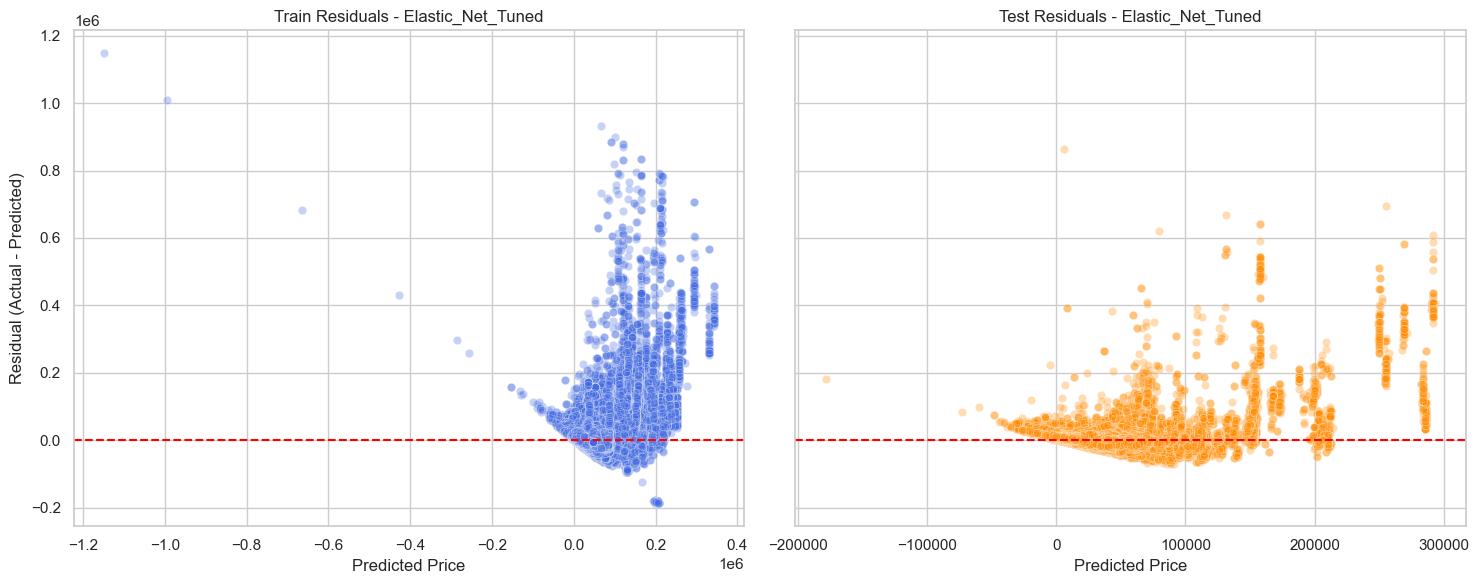


--- Hist_Gradient_Boosting_Tuned Overfitting Analysis ---
Metric     | Train           | Test            | Difference
------------------------------------------------------------
R² Score   | 0.9728          | 0.8910          | 0.0818
RMSE       | $4870.68        | $10360.48       | $5489.79
MAE        | $2365.05        | $3510.54        | $1145.49


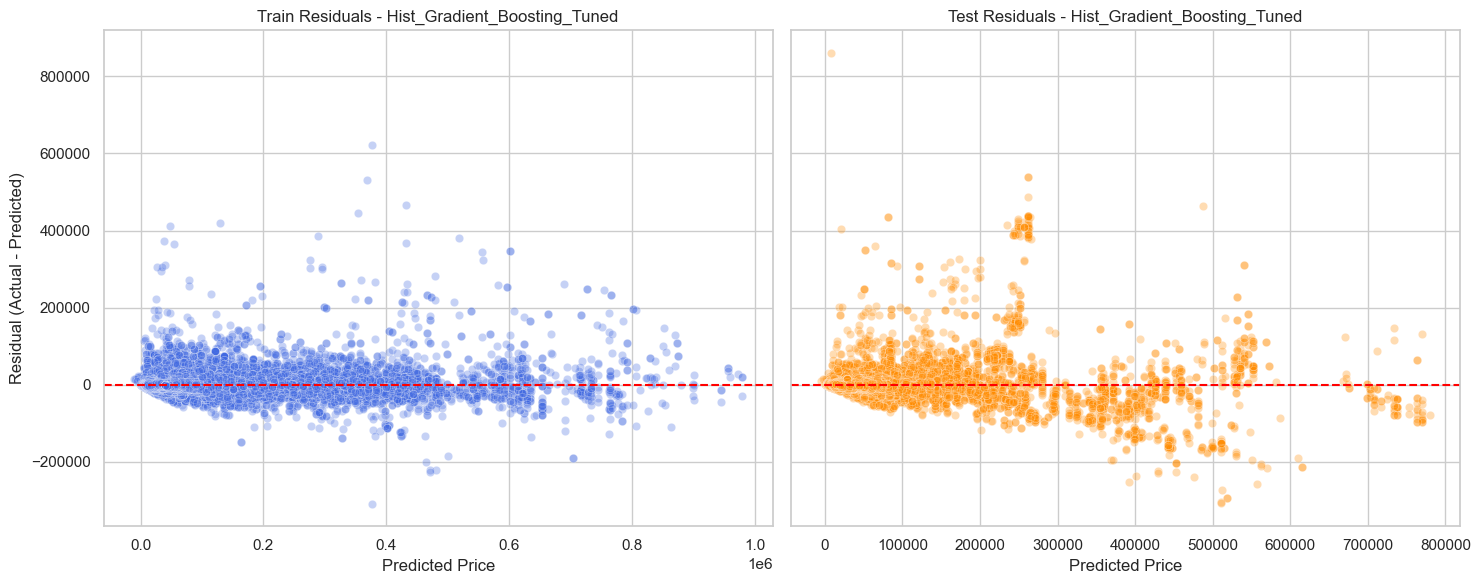


--- Multiple_Linear_Regression Overfitting Analysis ---
Metric     | Train           | Test            | Difference
------------------------------------------------------------
R² Score   | 0.9452          | 0.8912          | 0.0540
RMSE       | $6911.95        | $10351.35       | $3439.40
MAE        | $3225.19        | $4499.39        | $1274.20


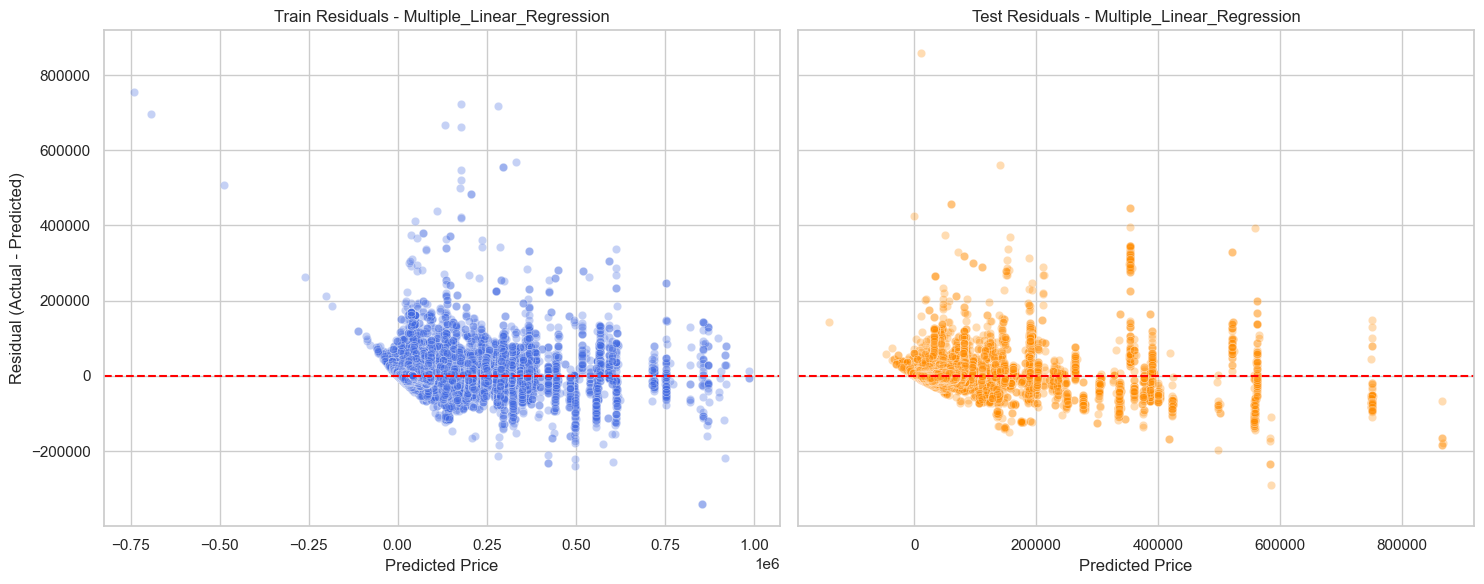


--- Random_Forest_Tuned Overfitting Analysis ---
Metric     | Train           | Test            | Difference
------------------------------------------------------------
R² Score   | 0.9924          | 0.8482          | 0.1441
RMSE       | $2581.83        | $12223.92       | $9642.10
MAE        | $1045.11        | $4648.50        | $3603.39


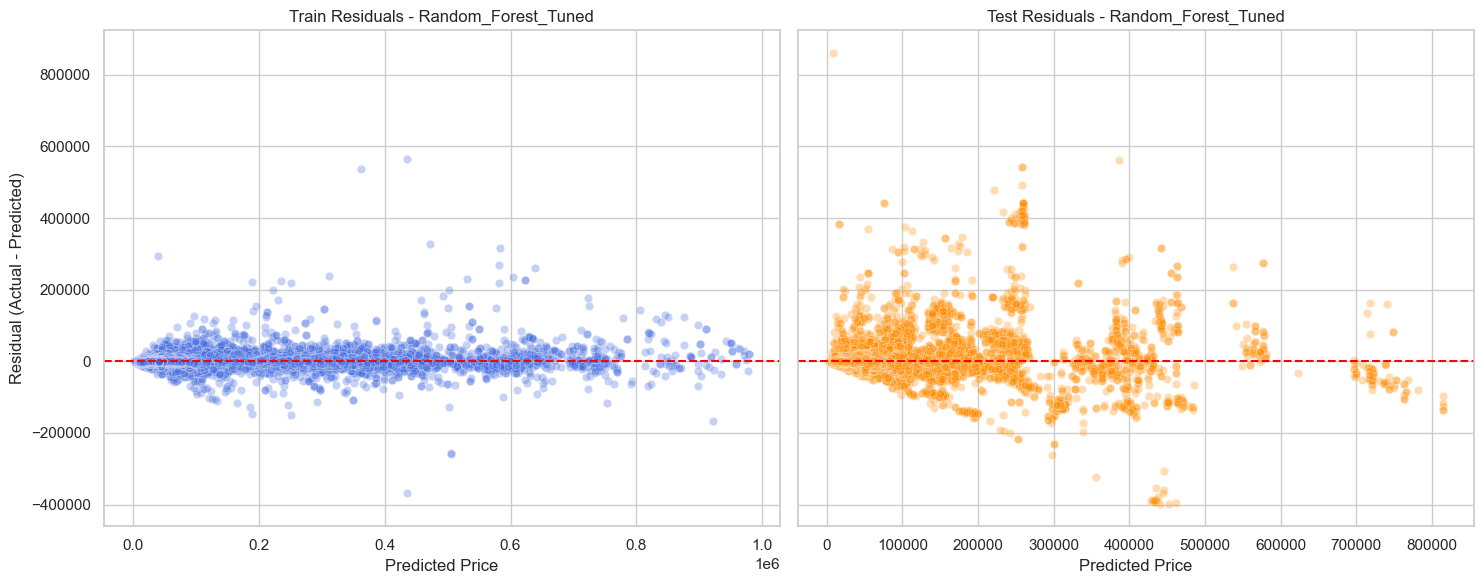

In [9]:
# 5. Overfitting Analysis
import sys
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Add the ML folder to the path so we can import the training script's functions
sys.path.append(str(BASE_DIR / "ML"))
from Price_ML_Models import load_and_split_data

print("\nLoading dataset and replicating the exact train/test split...")
X_train, y_train, X_test, y_test = load_and_split_data()

def print_overfitting_metrics(model_name, pipeline):
    # Predict on training data
    train_preds = pipeline.predict(X_train)
    train_r2 = r2_score(y_train, train_preds)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    train_mae = mean_absolute_error(y_train, train_preds)

    # Predict on testing data
    test_preds = pipeline.predict(X_test)
    test_r2 = r2_score(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_mae = mean_absolute_error(y_test, test_preds)

    print(f"\n--- {model_name} Overfitting Analysis ---")
    print(f"{'Metric':<10} | {'Train':<15} | {'Test':<15} | {'Difference'}")
    print("-" * 60)
    print(f"{'R² Score':<10} | {train_r2:<15.4f} | {test_r2:<15.4f} | {(train_r2 - test_r2):.4f}")
    print(f"{'RMSE':<10} | ${train_rmse:<14.2f} | ${test_rmse:<14.2f} | ${(test_rmse - train_rmse):.2f}")
    print(f"{'MAE':<10} | ${train_mae:<14.2f} | ${test_mae:<14.2f} | ${(test_mae - train_mae):.2f}")

    # Plot residuals side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    sns.scatterplot(x=train_preds, y=y_train - train_preds, ax=axes[0], alpha=0.3, color='royalblue')
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title(f"Train Residuals - {model_name}")
    axes[0].set_xlabel("Predicted Price")
    axes[0].set_ylabel("Residual (Actual - Predicted)")

    sns.scatterplot(x=test_preds, y=y_test - test_preds, ax=axes[1], alpha=0.3, color='darkorange')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title(f"Test Residuals - {model_name}")
    axes[1].set_xlabel("Predicted Price")

    plt.tight_layout()
    plt.show()

print("\nRunning Overfitting Analysis on loaded models...")
for name, model_pipeline in models.items():
    print_overfitting_metrics(name, model_pipeline)



--- SHAP Interpretations ---
Preparing transformed test data for SHAP...
Subsampling X_test from 337531 to 100 rows for SHAP calculations...

Calculating SHAP values for Random Forest on 100 samples...


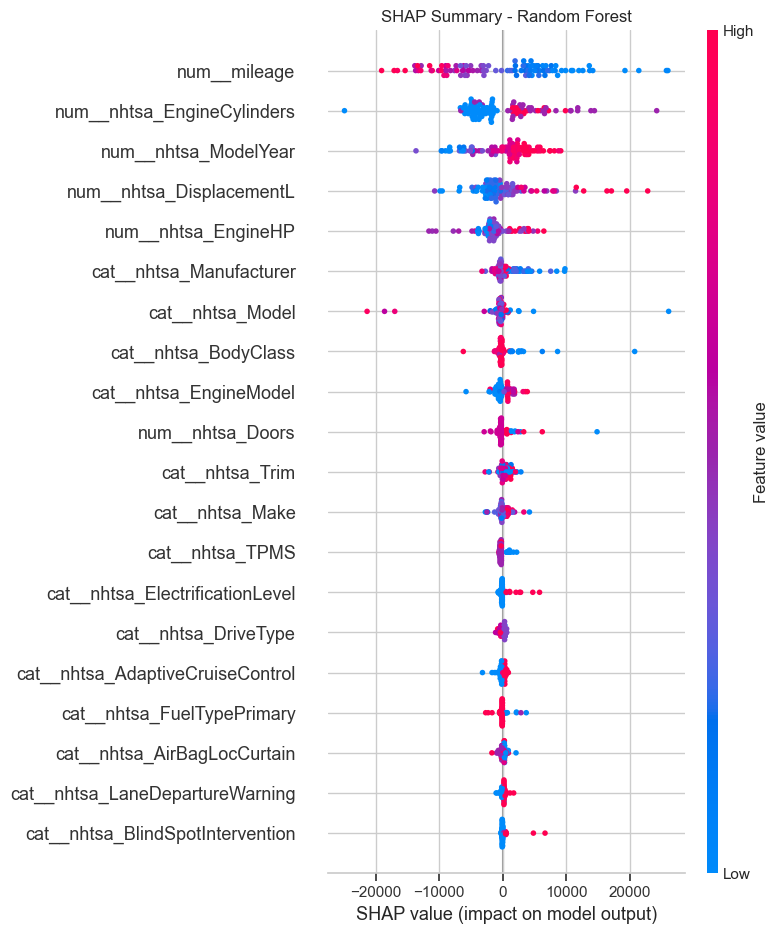


Calculating SHAP values for Hist Gradient Boosting on 100 samples...


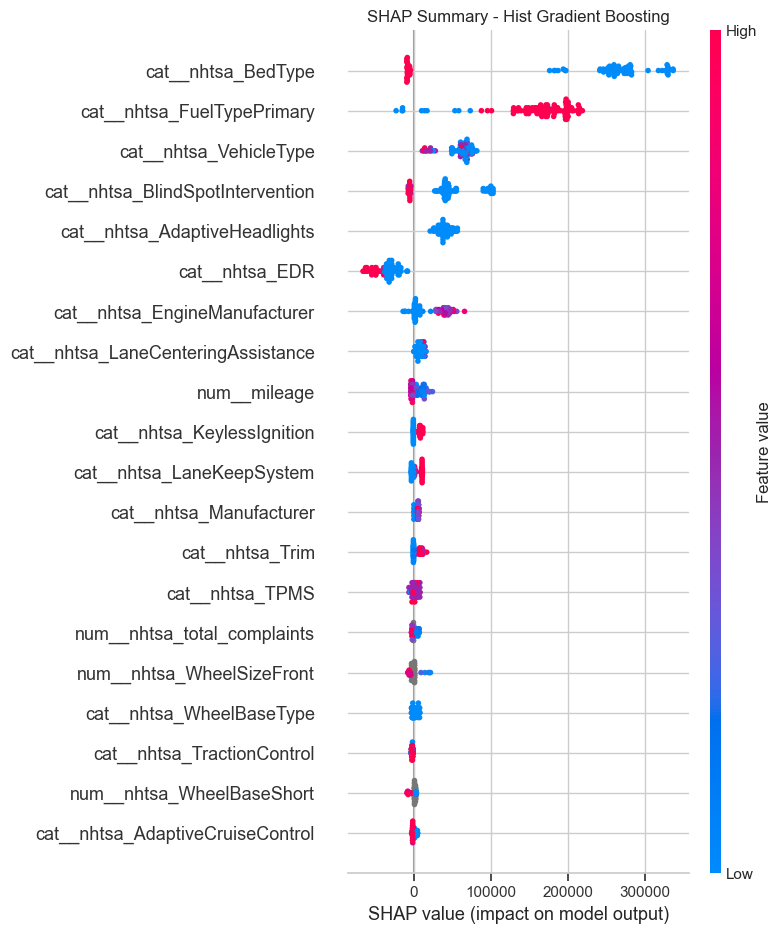

In [10]:
# 6. SHAP Interpretations
import shap

print("\n--- SHAP Interpretations ---")
print("Preparing transformed test data for SHAP...")

# Subsample X_test to max 20,000 rows for performance
n_samples = min(100, len(X_test))
print(f"Subsampling X_test from {len(X_test)} to {n_samples} rows for SHAP calculations...")
X_test_sampled = X_test.sample(n=n_samples, random_state=42)

# 6.1 Random Forest SHAP
if 'Random_Forest_Tuned' in models:
    print(f"\nCalculating SHAP values for Random Forest on {n_samples} samples...")
    rf_pipeline = models['Random_Forest_Tuned']
    rf_preprocessor = rf_pipeline.named_steps['preprocessor']
    rf_model = rf_pipeline.named_steps['model']

    # Transform test data and extract feature names
    X_test_rf_trans = rf_preprocessor.transform(X_test_sampled)
    if hasattr(X_test_rf_trans, "toarray"):
        X_test_rf_trans = X_test_rf_trans.toarray()

    feature_names_rf = rf_preprocessor.get_feature_names_out()
    X_test_rf_df = pd.DataFrame(X_test_rf_trans, columns=feature_names_rf)

    # Compute SHAP
    rf_explainer = shap.TreeExplainer(rf_model)
    rf_shap_values = rf_explainer.shap_values(X_test_rf_df)

    # Plot
    plt.figure()
    plt.title("SHAP Summary - Random Forest")
    shap.summary_plot(rf_shap_values, X_test_rf_df, show=False)
    plt.tight_layout()
    plt.show()

# 6.2 Hist Gradient Boosting SHAP
if 'Hist_Gradient_Boosting_Tuned' in models:
    print(f"\nCalculating SHAP values for Hist Gradient Boosting on {n_samples} samples...")
    hgbr_pipeline = models['Hist_Gradient_Boosting_Tuned']
    hgbr_preprocessor = hgbr_pipeline.named_steps['preprocessor']
    hgbr_model = hgbr_pipeline.named_steps['model']

    # Transform test data and extract feature names
    X_test_hgbr_trans = hgbr_preprocessor.transform(X_test_sampled)
    if hasattr(X_test_hgbr_trans, "toarray"):
        X_test_hgbr_trans = X_test_hgbr_trans.toarray()

    feature_names_hgbr = hgbr_preprocessor.get_feature_names_out()
    X_test_hgbr_df = pd.DataFrame(X_test_hgbr_trans, columns=feature_names_hgbr)

    # Compute SHAP
    hgbr_explainer = shap.TreeExplainer(hgbr_model)
    hgbr_shap_values = hgbr_explainer.shap_values(X_test_hgbr_df)

    # Plot
    plt.figure()
    plt.title("SHAP Summary - Hist Gradient Boosting")
    shap.summary_plot(hgbr_shap_values, X_test_hgbr_df, show=False)
    plt.tight_layout()
    plt.show()
